# Taylor Blast Wave: Experiment-Only Notebook

This notebook keeps only the experimental workflow:
- view the explosion photograph sequence,
- calibrate pixels to metres,
- compare measured radii with the best-fit theoretical scaling $r = k t^{2/5}$,
- estimate the explosion energy.

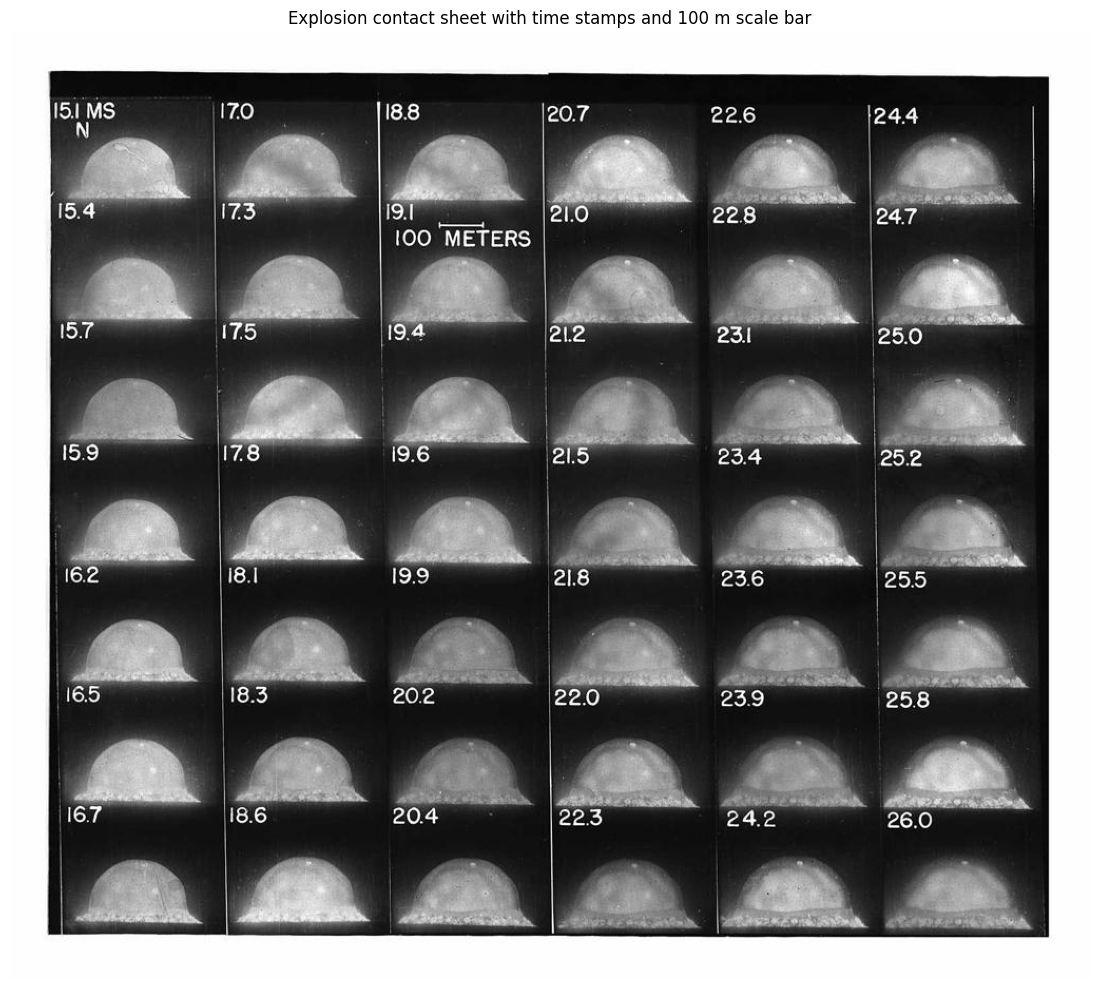

Image size: 1024 x 899 px


In [241]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

img = Image.open('blast.png').convert('RGB')
img_arr = np.array(img)

plt.figure(figsize=(12, 10))
plt.imshow(img_arr)
plt.axis('off')
plt.title('Explosion contact sheet with time stamps and 100 m scale bar')
plt.tight_layout()
plt.show()

print(f'Image size: {img.size[0]} x {img.size[1]} px')

## Calibration

Using the photograph, the 100 m scale bar is approximately **42 pixels** long.

In [242]:
scale_bar_pixels = 42
metres_per_pixel = 100 / scale_bar_pixels
metres_per_pixel

2.380952380952381

## Measured Characteristic Radius

These are approximate manual measurements from several frames. We keep two characteristic measurements:
- `radius_px_sides`: horizontal radius from the centreline to the visible side edge
- `radius_px_top`: vertical radius from the base line to the visible top

The theoretical scaling is retained as

$$r = k t^{2/5},$$

with only the constant $k$ fitted from the data.

In [243]:
# Global measurement toggle used everywhere below.
measurement_mode = 'top'  # change to 'top' to use the vertical measurement everywhere

In [244]:
data = pd.DataFrame({
    'time_ms': [15.1, 17.0, 18.8, 20.7, 22.6, 24.4],
    'radius_px_sides': [58, 60, 62, 64, 66, 68],
    'radius_px_top': [40, 41, 42, 43, 44, 45]
})

# Use the shared measurement mode for the scaling plot.
radius_col = f'radius_px_{measurement_mode}'

data['radius_px'] = data[radius_col]
data['time_s'] = data['time_ms'] / 1000
data['radius_m'] = data['radius_px'] * metres_per_pixel

k_fit = np.sum(data['radius_px'] * data['time_ms']**0.4) / np.sum(data['time_ms']**0.8)
tolerance_px = 1.5

data['radius_px_pred'] = k_fit * data['time_ms']**0.4
data['residual_px'] = data['radius_px'] - data['radius_px_pred']
data['abs_error_px'] = np.abs(data['residual_px'])
data['radius_m_pred'] = data['radius_px_pred'] * metres_per_pixel
data['abs_error_m'] = data['radius_m_pred'] - data['radius_m']
data['pct_error'] = 100 * data['abs_error_m'] / data['radius_m']

data

,time_ms,radius_px_sides,radius_px_top,radius_px,time_s,radius_m,radius_px_pred,residual_px,abs_error_px,radius_m_pred,abs_error_m,pct_error
0,15.1,58,40,40,0.0151,95.238095,38.218743,1.781257,1.781257,90.997007,-4.241088,-4.453142
1,17.0,60,41,41,0.0170,97.619048,40.074230,0.925770,0.925770,95.414834,-2.204214,-2.257975
2,18.8,62,42,42,0.0188,100.000000,41.720429,0.279571,0.279571,99.334354,-0.665646,-0.665646
3,20.7,64,43,43,0.0207,102.380952,43.358451,-0.358451,0.358451,103.234407,0.853455,0.833607
4,22.6,66,44,44,0.0226,104.761905,44.908546,-0.908546,0.908546,106.925110,2.163205,2.064878
5,24.4,68,45,45,0.0244,107.142857,46.306457,-1.306457,1.306457,110.253468,3.110611,2.903237


## Best-Fit Theory With Tolerance

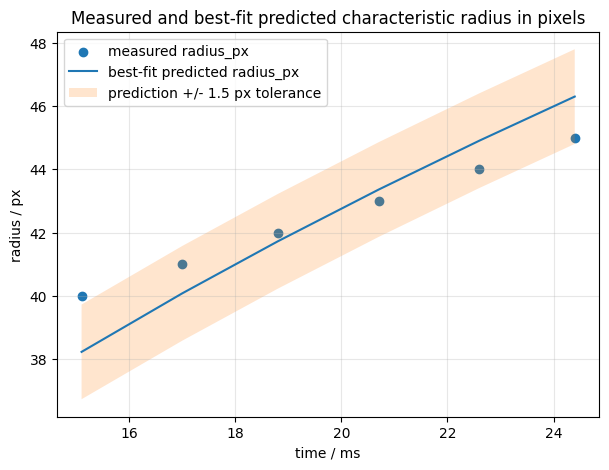

In [245]:
plt.figure(figsize=(7, 5))
plt.scatter(data['time_ms'], data['radius_px'], label='measured radius_px')
plt.plot(data['time_ms'], data['radius_px_pred'], label='best-fit predicted radius_px')
plt.fill_between(
    data['time_ms'],
    data['radius_px_pred'] - tolerance_px,
    data['radius_px_pred'] + tolerance_px,
    alpha=0.2,
    label=f'prediction +/- {tolerance_px:.1f} px tolerance'
)
plt.xlabel('time / ms')
plt.ylabel('radius / px')
plt.title('Measured and best-fit predicted characteristic radius in pixels')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [246]:
metrics = pd.Series({
    'k_fit_px_per_ms_0p4': k_fit,
    'tolerance_px': tolerance_px,
    'mean_abs_error_px': data['abs_error_px'].mean(),
    'rmse_px': np.sqrt(np.mean(data['residual_px']**2)),
    'mean_abs_percent_error': np.mean(np.abs(data['pct_error'])),
    'max_abs_percent_error': np.max(np.abs(data['pct_error'])),
    'points_within_tolerance': int((data['abs_error_px'] <= tolerance_px).sum()),
    'total_points': int(len(data)),
    'fraction_within_tolerance': (data['abs_error_px'] <= tolerance_px).mean(),
})
metrics

k_fit_px_per_ms_0p4          12.902849
tolerance_px                  1.500000
mean_abs_error_px             0.926675
rmse_px                       1.062141
mean_abs_percent_error        2.196414
max_abs_percent_error         4.453142
points_within_tolerance       5.000000
total_points                  6.000000
fraction_within_tolerance     0.833333
dtype: float64

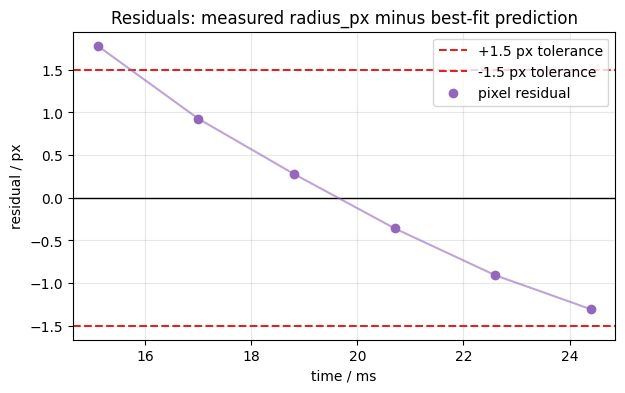

In [247]:
plt.figure(figsize=(7, 4))
plt.axhline(0, color='black', linewidth=1)
plt.axhline(tolerance_px, color='tab:red', linestyle='--', label=f'+{tolerance_px:.1f} px tolerance')
plt.axhline(-tolerance_px, color='tab:red', linestyle='--', label=f'-{tolerance_px:.1f} px tolerance')
plt.scatter(data['time_ms'], data['residual_px'], color='tab:purple', label='pixel residual')
plt.plot(data['time_ms'], data['residual_px'], color='tab:purple', alpha=0.6)
plt.xlabel('time / ms')
plt.ylabel('residual / px')
plt.title('Residuals: measured radius_px minus best-fit prediction')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Single-Frame Overlay at 19.1 ms

This cell overlays the theoretical radius on a **separate 19.1 ms image** from the fitted law

$$r = k t^{2/5}.$$

Use a local file called `191ms.png` for the exact standalone picture you want to analyze. The centre position is adjustable because the bright fireball is not perfectly circular.

Frame scale bar: 75 px = 100 m  (1.333 m/px)
Centre: cx = 141.4 px, cy = 200.5 px
Theoretical radius: 100.0 m = 75.0 px (in 191ms.png)


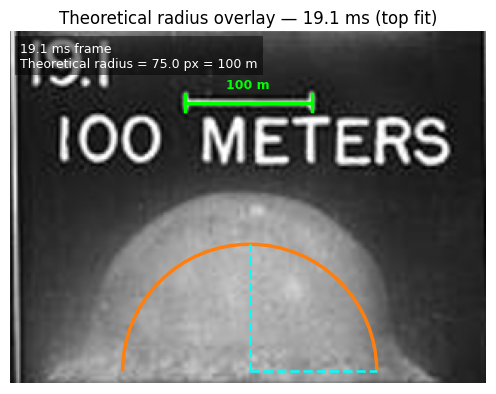

In [248]:
from matplotlib.patches import Arc
from pathlib import Path

frame_path = Path('191ms.png')
if not frame_path.exists():
    raise FileNotFoundError('Place the desired standalone image in this folder as 191ms.png')

frame = np.array(Image.open(frame_path).convert('RGB'))
h, w = frame.shape[:2]

t_frame_ms = 19.1

# Calibrate from the photograph's own 100-m scale bar in 191ms.png.
# The bar runs from x=103 (left tick) to x=178 (right tick) = 75 px = 100 m.
scale_x0_frame = 103
scale_x1_frame = 178
scale_bar_px_frame = scale_x1_frame - scale_x0_frame   # 75 px = 100 m
scale_y_frame = 42                                       # row of the scale bar line

metres_per_pixel_frame = 100 / scale_bar_px_frame

# Theoretical radius: convert k_fit to metres, then back to frame pixels.
k_fit_m = k_fit * metres_per_pixel              # m / ms^0.4  (contact-sheet calibration)
r_theory_m = k_fit_m * t_frame_ms**0.4         # metres at t_frame_ms
r_theory_px = r_theory_m / metres_per_pixel_frame

# Blast centre position (tune these to align with the fireball).
ground_above_m = 10    # ground level this many metres above the image bottom
cx_offset_m   = -10   # shift centre left (negative) or right (positive) from image midpoint
cx = 0.53 * w + cx_offset_m / metres_per_pixel_frame
cy = h - ground_above_m / metres_per_pixel_frame

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.imshow(frame)

# Theoretical blast radius arc (semi-circle above ground level).
ax.add_patch(
    Arc(
        (cx, cy),
        width=2 * r_theory_px,
        height=2 * r_theory_px,
        theta1=180,
        theta2=360,
        color='tab:orange',
        linewidth=2.5,
    )
)
ax.plot([cx, cx + r_theory_px], [cy, cy], color='cyan', linestyle='--', linewidth=1.8)
ax.plot([cx, cx], [cy, cy - r_theory_px], color='cyan', linestyle='--', linewidth=1.8)

# 100-metre reference bar overlaid on the photograph's own scale bar.
bar_c = 'lime'
bar_lw = 2.5
ax.plot([scale_x0_frame, scale_x1_frame], [scale_y_frame, scale_y_frame],
        color=bar_c, linewidth=bar_lw)
ax.plot([scale_x0_frame, scale_x0_frame], [scale_y_frame - 5, scale_y_frame + 5],
        color=bar_c, linewidth=bar_lw)
ax.plot([scale_x1_frame, scale_x1_frame], [scale_y_frame - 5, scale_y_frame + 5],
        color=bar_c, linewidth=bar_lw)
ax.text((scale_x0_frame + scale_x1_frame) / 2, scale_y_frame - 7, '100 m',
        color=bar_c, fontsize=9, ha='center', va='bottom', fontweight='bold')

ax.text(
    6, 6,
    f'19.1 ms frame\nTheoretical radius = {r_theory_px:.1f} px = {r_theory_m:.0f} m',
    color='white', fontsize=9, ha='left', va='top',
    bbox=dict(facecolor='black', alpha=0.50, edgecolor='none'),
)

print(f'Frame scale bar: {scale_bar_px_frame} px = 100 m  ({metres_per_pixel_frame:.3f} m/px)')
print(f'Centre: cx = {cx:.1f} px, cy = {cy:.1f} px')
print(f'Theoretical radius: {r_theory_m:.1f} m = {r_theory_px:.1f} px (in 191ms.png)')

ax.set_xlim(0, w)
ax.set_ylim(h, 0)
ax.set_title(f'Theoretical radius overlay — 19.1 ms ({measurement_mode} fit)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [249]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

_frame = np.array(Image.open('191ms.png').convert('RGB'))
_h, _w = _frame.shape[:2]

# Frame calibration (same as overlay cell above)
_scale_x0, _scale_x1, _scale_y = 103, 178, 42
_mpx = 100 / (_scale_x1 - _scale_x0)   # metres per pixel in this frame
_cx  = 141.4                             # blast centre x (px)
_cy  = 196.75                            # blast centre y (px)

_t_ms  = 19.1
_t_s   = _t_ms / 1000
_rho   = 1.2    # kg/m³  (air density)
_r_theory_m = k_fit * metres_per_pixel * _t_ms**0.4   # theoretical radius in metres

def _update(radius_m):
    r_px = radius_m / _mpx
    E_J  = _rho * radius_m**5 / _t_s**2
    E_kt = E_J / 4.184e12

    fig = plt.figure(figsize=(6.5, 5.2))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.08)

    # --- photograph with overlay ---
    ax_img = fig.add_subplot(gs[0])
    ax_img.imshow(_frame)
    ax_img.add_patch(Arc((_cx, _cy), 2*r_px, 2*r_px,
                         theta1=180, theta2=360,
                         color='tab:orange', linewidth=2.5))
    ax_img.plot([_cx, _cx + r_px], [_cy, _cy],   color='cyan', ls='--', lw=1.8)
    ax_img.plot([_cx, _cx],        [_cy, _cy - r_px], color='cyan', ls='--', lw=1.8)

    # theoretical radius marker
    ax_img.axvline(_cx + _r_theory_m/_mpx, color='yellow', lw=1, ls=':',
                   label=f'theory {_r_theory_m:.0f} m')

    # 100 m scale bar
    for x in [_scale_x0, _scale_x1]:
        ax_img.plot([x, x], [_scale_y-5, _scale_y+5], color='lime', lw=2.5)
    ax_img.plot([_scale_x0, _scale_x1], [_scale_y, _scale_y], color='lime', lw=2.5)
    ax_img.text((_scale_x0+_scale_x1)/2, _scale_y-7, '100 m',
                color='lime', fontsize=9, ha='center', va='bottom', fontweight='bold')

    ax_img.text(4, 4, f'r = {radius_m:.0f} m', color='white', fontsize=10,
                va='top', bbox=dict(fc='black', alpha=0.55, ec='none'))
    ax_img.set_xlim(0, _w); ax_img.set_ylim(_h, 0); ax_img.axis('off')
    ax_img.set_title(f'Theoretical radius overlay — {_t_ms} ms', fontsize=11)

    # --- energy bar ---
    ax_e = fig.add_subplot(gs[1])
    max_kt = 100
    frac   = min(E_kt / max_kt, 1.0)
    color  = plt.cm.RdYlGn_r(frac)
    ax_e.barh(0, E_kt, color=color, height=0.6)
    ax_e.axvline(_rho * _r_theory_m**5 / _t_s**2 / 4.184e12,
                 color='yellow', lw=1.5, ls=':', label='theory')
    ax_e.set_xlim(0, max_kt)
    ax_e.set_yticks([])
    ax_e.set_xlabel('Energy  (kt TNT)', fontsize=10)
    ax_e.text(E_kt + 1, 0, f'{E_kt:.1f} kt', va='center', fontsize=10, fontweight='bold')
    ax_e.legend(loc='upper right', fontsize=8)

    plt.show()

r_slider = widgets.IntSlider(
    value=int(round(_r_theory_m)),
    min=50, max=300, step=1,
    description='Radius (m)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px'),
)

widgets.interact(_update, radius_m=r_slider)

interactive(children=(IntSlider(value=100, description='Radius (m)', layout=Layout(width='500px'), max=300, mi…

<function __main__._update(radius_m)>

## Explosion Energy Estimate

Using the order-of-magnitude estimate

$$E \sim \frac{\rho r^5}{t^2},$$

with air density $\rho \approx 1.2\ \mathrm{kg\,m^{-3}}$.

The energy estimate below uses the same `measurement_mode` toggle as the scaling section above.

In [250]:
energy_radius_col = f'radius_px_{measurement_mode}'

data['energy_radius_px'] = data[energy_radius_col]
data['energy_radius_m'] = data['energy_radius_px'] * metres_per_pixel

print(f'Using {energy_radius_col} for the energy estimate')

Using radius_px_top for the energy estimate


In [251]:
rho = 1.2

data['E_est_J'] = rho * data['energy_radius_m']**5 / data['time_s']**2
data['E_est_kilotons_TNT'] = data['E_est_J'] / 4.184e12

energy_summary = data[[
    'time_ms', 'energy_radius_px', 'energy_radius_m', 'E_est_J', 'E_est_kilotons_TNT'
]].copy()
energy_summary.columns = ['time_ms', 'radius_px_used', 'radius_m_used', 'E_est_J', 'E_est_kilotons_TNT']
energy_summary

,time_ms,radius_px_used,radius_m_used,E_est_J,E_est_kilotons_TNT
0,15.1,40,95.238095,4.123641e+13,9.855739
1,17.0,41,97.619048,3.680919e+13,8.797607
2,18.8,42,100.000000,3.395201e+13,8.114726
3,20.7,43,102.380952,3.150187e+13,7.529128
4,22.6,44,104.761905,2.964704e+13,7.085812
5,24.4,45,107.142857,2.845887e+13,6.801834


In [252]:
E_mean = data['E_est_J'].mean()
kt_mean = E_mean / 4.184e12

print(f'Mean estimated energy: {E_mean:.3e} J')
print(f'Mean estimated yield: {kt_mean:.2f} kilotons TNT')

Mean estimated energy: 3.360e+13 J
Mean estimated yield: 8.03 kilotons TNT
